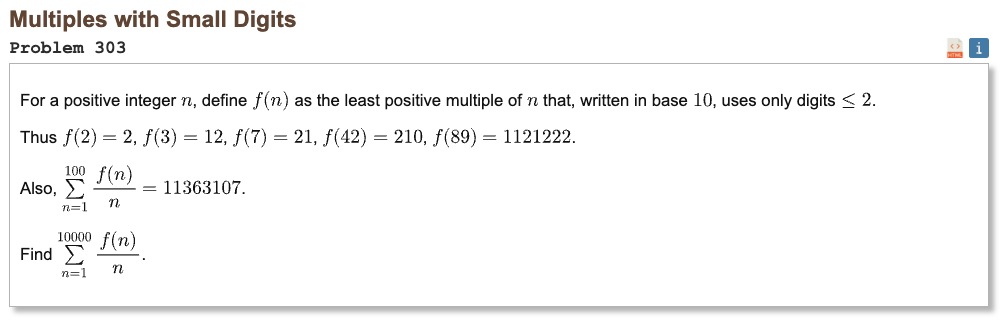

## Initial approach

* for each number n, the goal is to find the smallest multiple made only of digits 0, 1, 2, so this becomes a search problem over digit strings
* instead of generating numbers directly, work with remainders modulo n, because two numbers with the same remainder behave the same in terms of divisibility
* start from the smallest valid numbers and grow them by appending digits 0, 1, or 2, while tracking their remainder
* use a breadth first search so the first time a remainder becomes zero, that number is guaranteed to be the smallest valid multiple
* keep a visited array for remainders to avoid infinite loops and repeated work
* once the smallest valid multiple is found, divide it by n and add the result to the total
* repeat this process for all n up to 10000, then sum everything including the given special case for 9999

In [1]:
from collections import deque

def smallest_multiple(n):
    visited = [False] * n
    q = deque()

    for d in (1, 2):
        r = d % n
        q.append((r, str(d)))
        visited[r] = True

    while q:
        r, s = q.popleft()
        if r == 0:
            return int(s)

        for d in (0, 1, 2):
            nr = (r * 10 + d) % n
            if not visited[nr]:
                visited[nr] = True
                q.append((nr, s + str(d)))

def solve(limit):
    total = 0
    for n in range(1, limit + 1):
        m = smallest_multiple(n)
        total += m // n
    return total

In [2]:
%%time
result = solve(10000)
print("Result:", result)

Result: 1111981904675169
CPU times: user 8.07 s, sys: 35.2 ms, total: 8.1 s
Wall time: 8.18 s
